In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
import os
import yaml
from sklearn.metrics import r2_score, mean_absolute_error
from airquality.analysis.postprocessing import aggregate_n_params, aggregate_predictions

def get_sindy_scores(sindy_path):
    score_df = pd.DataFrame(columns=['num_params', 'r2_score', 'tau'])
    for root, dirs, files in os.walk(sindy_path):
        if 'config.yaml' in files:
            with open(os.path.join(root, 'config.yaml'), 'r') as f:
                config = yaml.safe_load(f)

            ii = len(score_df)
            score_df.loc[ii, 'num_params'] = aggregate_n_params(root)[0]
            score_df.loc[ii, 'tau'] = config['model']['optimizer']['threshold']

            pred_df = aggregate_predictions(root, overwrite=True, csv_kwargs={'converters': {'date_local': lambda x: pd.Period(x, freq='D')}})
            score_df.loc[ii, 'r2_score'] = r2_score(pred_df['Observed'], pred_df['Predicted'])
            score_df.loc[ii, 'mean_absolute_error'] = mean_absolute_error(pred_df['Observed'], pred_df['Predicted'])
    
    score_df.to_csv(f'{sindy_path}/score_curve.csv', index=False)
    return score_df

get_sindy_scores(os.path.join(os.environ['MODELS_DIR'], 'coi/GAM/lag7/stlsq_threshold')).set_index('tau').sort_index()
get_sindy_scores(os.path.join(os.environ['MODELS_DIR'], 'coi/GLM/lag7/stlsq_threshold')).set_index('tau').sort_index()

,num_params,r2_score,mean_absolute_error
tau,,,
0.01001,83.0,0.413372,2.599772
0.015671,82.666667,0.413372,2.599771
0.024533,82.666667,0.413372,2.599771
0.038407,82.666667,0.413372,2.599771
0.060128,82.666667,0.413372,2.599771
0.094131,82.666667,0.413372,2.599771
0.147364,82.0,0.413371,2.599762
0.230703,81.666667,0.413354,2.599809
0.361171,81.333333,0.413369,2.599788


In [3]:
import os
import yaml
from airquality.analysis.postprocessing import aggregate_effects

def get_sindy_effects(sindy_path):
    risk_df = []
    for root, dirs, files in os.walk(sindy_path):
        if 'config.yaml' in files:
            with open(os.path.join(root, 'config.yaml'), 'r') as f:
                config = yaml.safe_load(f)

            tau_df = aggregate_effects(root)
            tau_df['tau'] = config['model']['optimizer']['threshold']
            risk_df.append(tau_df)
            
    risk_df = pd.concat(risk_df)
    risk_df = risk_df.set_index(['parameter', 'tau']).sort_index()

    risk_df.to_csv(f'{sindy_path}/effect_curves.csv')
    return risk_df

get_sindy_effects(os.path.join(os.environ['MODELS_DIR'], 'coi/GLM/lag7/stlsq_threshold')).dropna()
get_sindy_effects(os.path.join(os.environ['MODELS_DIR'], 'coi/GAM/lag7/stlsq_threshold')).dropna()

mean  variance
parameter                 tau                          
AverageDryBulbTemperature 0.010010   0.891125  0.011499
                          0.015671   0.891125  0.011499
                          0.024533   0.891125  0.011499
                          0.038407   0.891125  0.011499
                          0.060128   0.891155  0.011495
...                                       ...       ...
log_covid                 20.400952  0.840189  0.000127
                          26.265278  0.845289  0.000156
                          31.938184  0.841316  0.000163
                          36.238983  0.842788  0.000164
                          50.000000  0.835148  0.000094

[250 rows x 2 columns]

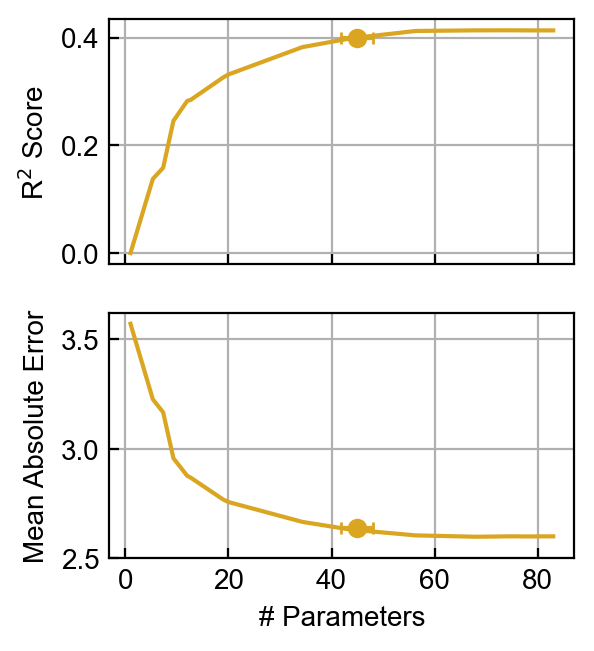

In [8]:
import os
import yaml
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection

import yaml
from airquality.analysis.plotting import plot_effect, labels_map
from airquality.analysis.postprocessing.aggregate import iqr_score

def plot_sindy_results(ax, 
                       sindy_path,
                       final_path,
                       label, 
                       color='goldenrod'):
    risk_df = pd.read_csv(f'{sindy_path}/effect_curves.csv').sort_values(['parameter', 'tau'])
    score_df = pd.read_csv(f'{sindy_path}/score_curve.csv').sort_values('tau')

    # Link colormap normalization to tau
    cmap = LinearSegmentedColormap.from_list('cmap', ['white', color])
    c = 1 - np.log(score_df['tau'])
    norm = plt.Normalize(np.min(c) - np.ptp(c), np.max(c))

    ax[0].plot(score_df['num_params'], score_df['r2_score'], color=color)
    ax[1].plot(score_df['num_params'], score_df['mean_absolute_error'], color=color)

    n_params, std_params = aggregate_n_params(final_path)
    pred_df = aggregate_predictions(final_path)

    for ii, score_func in enumerate([r2_score, mean_absolute_error]):
        scores = pred_df.groupby('trial_index').apply(lambda group : score_func(group['Observed'], group['Predicted']), include_groups=False)
        scores = pd.DataFrame({'score': scores.values}, index=scores.index)
        ax[ii].errorbar(
            n_params, 
            scores['score'].mean(), 
            xerr=std_params,
            yerr=scores['score'].std(),  
            label=label, 
            color=color, 
            capsize=2, 
            marker='o'
        )

fig, ax = plt.subplots(2, 1, figsize=(3, 3.5), dpi=200, sharex=True)
plot_sindy_results(ax, 
                   sindy_path=os.path.join(os.environ['MODELS_DIR'], 'coi/GLM/lag7/stlsq_threshold'),
                   final_path=os.path.join(os.environ['MODELS_DIR'], 'coi/GLM/lag7/stlsq'),
                   label='Sparse GLM', color='goldenrod')

ax[0].set(ylabel='R$^2$ Score', yticks=[0, 0.2, 0.4])
ax[1].set(xlabel='# Parameters', ylabel='Mean Absolute Error', yticks=[2.5, 3.0, 3.5])
plt.savefig(os.path.join(os.environ['MODELS_DIR'], 'coi', 'sparsity_curves.pdf'), bbox_inches='tight', dpi=200)